# Анализ данных о книгах
## Источник данных
Набор данных - [Goodreads-books data set](https://www.kaggle.com/datasets/jealousleopard/goodreadsbooks) разработан Soumik. 



# ✔ 1. Краткое содержание dataset - описание данных

### Таблица **book** - Подробная информация о книгах
*  Данные о книгах с различным признаками. Доступные столбцы:
  * "bookID", "title", "authors", "average_rating", "isbn", "isbn13", "language_code", "num_pages","ratings_count", "text_reviews_count", "publication_date", "publisher".


### Краткая информация о столбцах-признаках:

* "bookID" - уникальный идентификационный номер для каждой книги,
* "title" - название, под которым была опубликована книга,
* "authors" - имена авторов книги,
* "average_rating" - средняя оценка, полученная книгой в целом,
* "isbn" - еще один уникальный номер для идентификации книги - международный стандартный номер книги,
* "isbn13" - 13-значный ISBN для идентификации книги вместо стандартного 11-значного ISBN,
* "language_code" - помогает понять, на каком языке написана книга,
* "num_pages" - количество страниц, содержащихся в книге,
* "ratings_count" - общее количество оценок, полученных книгой,
* "text_reviews_count"  - общее количество письменных текстовых рецензий, полученных на книгу,
* "publication_date" - дата публикации книги,
* "publisher" - издатель.


# ✔ 1. Предобработка данных:

1.1 Выбор наиболее релевантных данных для анализа: подойдут столбцы "bookID","title", "authors", "average_rating","num_pages",
"ratings_count", "num_pages","ratings_count","publication_date", "publisher". Отброшенные столбцы - "isbn", "isbn13", "text_reviews_count".

1.2 Так как в предоставленной БД не был включен столбик "genres" сгенерируем его рандомно для дальнейшего создания запроса SQL при помощи библиотеки random. Для дальнейшей предобработки выполнен импорт библиотеки pandas.

In [2]:
import pandas as pd  #импорт библиотек pandas и random
import random

data = pd.read_csv("books.csv")  # Загрузка данных

genres = [
    "Fantasy", "Science Fiction", "Mystery", "Romance", "Historical Fiction", 
    "Thriller", "Adventure", "Biography", "Nonfiction", "Contemporary"
]

# Добавляем столбец "жанры" с рандомными значениями
data['genres'] = [random.choice(genres) for _ in range(len(data))]

print(data.head())

  bookID                                              title  \
0      1  Harry Potter and the Half-Blood Prince (Harry ...   
1      2  Harry Potter and the Order of the Phoenix (Har...   
2      4  Harry Potter and the Chamber of Secrets (Harry...   
3      5  Harry Potter and the Prisoner of Azkaban (Harr...   
4      8  Harry Potter Boxed Set  Books 1-5 (Harry Potte...   

                      authors  average_rating        isbn        isbn13  \
0  J.K. Rowling/Mary GrandPré            4.57  0439785960  9.780440e+12   
1  J.K. Rowling/Mary GrandPré            4.49  0439358078  9.780439e+12   
2                J.K. Rowling            4.42  0439554896  9.780440e+12   
3  J.K. Rowling/Mary GrandPré            4.56  043965548X  9.780440e+12   
4  J.K. Rowling/Mary GrandPré            4.78  0439682584  9.780440e+12   

  language_code    num_pages  ratings_count  text_reviews_count  \
0           eng        652.0      2095690.0             27591.0   
1           eng        870.0      21

1.3 Создание первоначальной резервной копии с помощью библиотеки shutil для восстановления данных,если оно понадобится.

In [3]:
import shutil

def backup_file_function(source_file, backup_file):
    
  try:
    shutil.copy2(source_file, backup_file)
    print(f"Backup created: {source_file} to {backup_file}")
  except Exception as e:
    print(f"Backup error: {e}")

source_file = "books.csv"
backup_file = "backup_books.csv"
backup_file_function(source_file, backup_file)

Backup created: books.csv to backup_books.csv


1.4 Избавляемся от нерелевантных столбцов:

In [4]:
data = data.drop('isbn', axis=1)
data = data.drop('isbn13', axis=1)
data = data.drop('text_reviews_count', axis=1)

1.5 Просмотрим название столбцов:

In [5]:
print(data.columns)

Index(['bookID', 'title', 'authors', 'average_rating', 'language_code',
       '  num_pages', 'ratings_count', 'publication_date', 'publisher;;;',
       'genres'],
      dtype='object')


Переименуем столбец '  num_pages' в 'num_pages',а также 'publisher;;;' в 'publisher' для дальнейшей обработки.

In [6]:
data = data.rename(columns={'  num_pages': 'num_pages'})
data = data.rename(columns={'publisher;;;': 'publisher'})

Удалим ненужные символы ';' в колонке 'publisher':

In [7]:
data['publisher'] = data['publisher'].str.strip(';').str.replace(';', '')

In [8]:
def clean_ratings_df(data, average_rating):
  """Удаляет пробелы и заменяет запятые на точки в столбце рейтинга датафрейма."""
  data[average_rating] = data[average_rating].astype(str)  # Преобразование в строковый тип
  data[average_rating] = data[average_rating].str.replace(" ", "")
  data[average_rating] = data[average_rating].astype(float)  # Преобразование обратно в числовой тип
  return data

In [9]:
print(data.head())

  bookID                                              title  \
0      1  Harry Potter and the Half-Blood Prince (Harry ...   
1      2  Harry Potter and the Order of the Phoenix (Har...   
2      4  Harry Potter and the Chamber of Secrets (Harry...   
3      5  Harry Potter and the Prisoner of Azkaban (Harr...   
4      8  Harry Potter Boxed Set  Books 1-5 (Harry Potte...   

                      authors  average_rating language_code  num_pages  \
0  J.K. Rowling/Mary GrandPré            4.57           eng      652.0   
1  J.K. Rowling/Mary GrandPré            4.49           eng      870.0   
2                J.K. Rowling            4.42           eng      352.0   
3  J.K. Rowling/Mary GrandPré            4.56           eng      435.0   
4  J.K. Rowling/Mary GrandPré            4.78           eng     2690.0   

   ratings_count publication_date        publisher           genres  
0      2095690.0        9/16/2006  Scholastic Inc.        Adventure  
1      2153167.0         9/1/2004  S

1.6 Заполняем пропущенные значения в столбце "publication_date" 0:

In [10]:
data['publication_date'] = data['publication_date'].replace(pd.NaT, 0)

1.7 Заполняем пропущенные значения в других столбцах  нулями:

In [11]:
data.fillna(0, inplace=True)

1.8 Удаляем дубликаты:

In [12]:
data.drop_duplicates(inplace=True)

1.9 Преобразуем пропущенные данные в столбце bookID в 0:

In [13]:
def convert_to_int(value):
    try:
        return int(value)
    except ValueError:
        return 0 

data['bookID'] = data['bookID'].apply(convert_to_int)

1.10 Преобразование в верным форматам данных в столбцах. Импорт библиотеки numpy.

In [14]:
import numpy as np
from datetime import datetime

#Преобразуем столбец "bookID" в формат int
data["bookID"] = data["bookID"].astype(int)  

#Преобразуем столбец "ratings_count"  в формат int
data["ratings_count"] = data["ratings_count"].astype(int)

data["num_pages"] = data["num_pages"].astype(int)

# Преобразуем столбец "publication_date" в формат datetime
data["publication_date"] = pd.to_datetime(data["publication_date"], errors='coerce')

# Преобразуем столбец "average_rating" в числовой формат
data["average_rating"] = data["average_rating"].astype(float)

1.11 Описание структуры данных:

In [16]:
print(data.info()) 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11125 entries, 0 to 11124
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   bookID            11125 non-null  int64         
 1   title             11125 non-null  object        
 2   authors           11125 non-null  object        
 3   average_rating    11125 non-null  float64       
 4   language_code     11125 non-null  object        
 5   num_pages         11125 non-null  int64         
 6   ratings_count     11125 non-null  int64         
 7   publication_date  11096 non-null  datetime64[ns]
 8   publisher         11125 non-null  object        
 9   genres            11125 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(3), object(5)
memory usage: 869.3+ KB
None


1.12 Описание типов переменных:

In [17]:
print(data.dtypes)

bookID                       int64
title                       object
authors                     object
average_rating             float64
language_code               object
num_pages                    int64
ratings_count                int64
publication_date    datetime64[ns]
publisher                   object
genres                      object
dtype: object


1.13 Сохранение измененного датасета для дальнейшей обработки в SQL Server Management Studio:

In [18]:
data.to_csv('books_updated_data.csv', index=False)

# 3.	Визуализация данных в Jupyter Notebook:

## 3.1 Построение гистограммы распределения рейтинга книг.

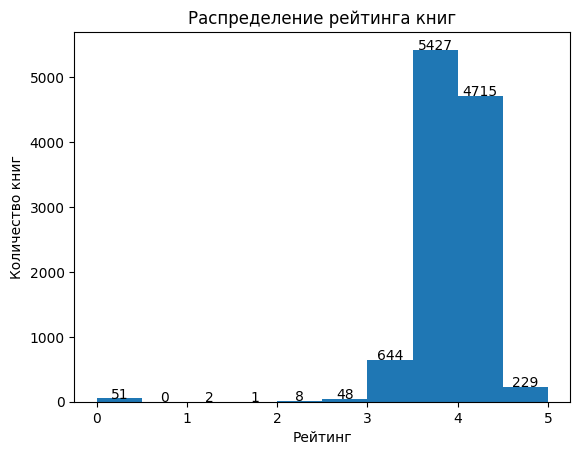

In [22]:
import matplotlib.pyplot as plt

#добавление подписи значений столбцов
def addlabels(x,y):     
    for i in range(len(x)-1):
     x_center = (x[i] + x[i + 1]) / 2
     plt.text(x_center, y[i], str(int(y[i])), ha='center')

#построение гистограммы распределения рейтинга книг
plt.hist(data['average_rating'], bins=10,color='blue')
plt.xlabel('Рейтинг')
plt.ylabel('Количество книг')
plt.title('Распределение рейтинга книг')

# Получаем значения для подписи столбцов
n, bins, patches = plt.hist(data['average_rating'], bins=10)

# Вызываем функцию addlabels для добавления подписей
addlabels(bins, n)

plt.show()

* Весь датасет books содержит всего 10352 книги.
* С помощью гистограммы распределения рейтинга книг можно сказать,что
  * 5427 книг имеют средний рейтинг от 3,5 до 4,т.е этот интервал самый распространенный;
  * 4715 книг имеют средний рейтинг от 4 до 4,5;
  * 644 книги с рейтингом от 3 до 3,5;
  * остальные интервалы содержат меньшее количество книг,следовательно менее распространенные.

## 3.2 С помощью диаграммы столбцов сравните количество книг по жанрам.

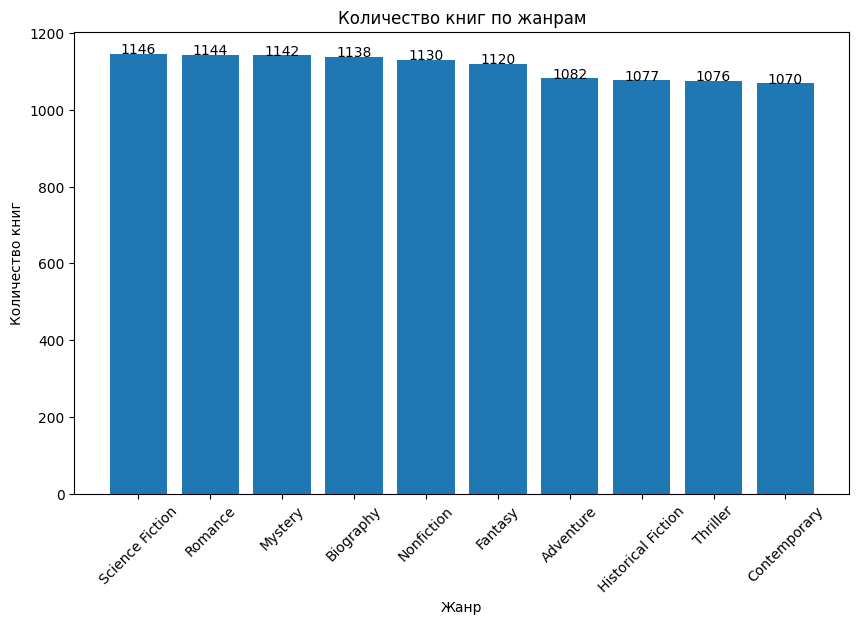

In [20]:
genre_counts = data['genres'].value_counts()

#добавление подписи значений столбцов
def addlabels(x,y):
    for i in range(len(x)):
     x_pos = i 
     plt.text(x_pos, y[i], str(int(y[i])), ha='center')
        
# Строим диаграмму столбцов
plt.figure(figsize=(10, 6))
plt.bar(genre_counts.index, genre_counts.values)
plt.title('Количество книг по жанрам')
plt.xlabel('Жанр')
plt.ylabel('Количество книг')
plt.xticks(rotation=45) 

# Получаем значения для подписи столбцов
n = genre_counts.values  #  Получаем значения для подписи
bins = genre_counts.index  

# Вызываем функцию addlabels для добавления подписей
addlabels(bins, n)

plt.show()

Т.к. исходный датасет не имел признака 'genres',он был сгенерирован рандомно через библиотеку random,следовательно количество жанров по книгам сравнительно одинаково,но при этом имея небольшую тенденцию в сторону уменьшения кол-ва от жанра Thriller до Mystery.

## 3.3 Scatter plot зависимости рейтинга книги от количества оценок

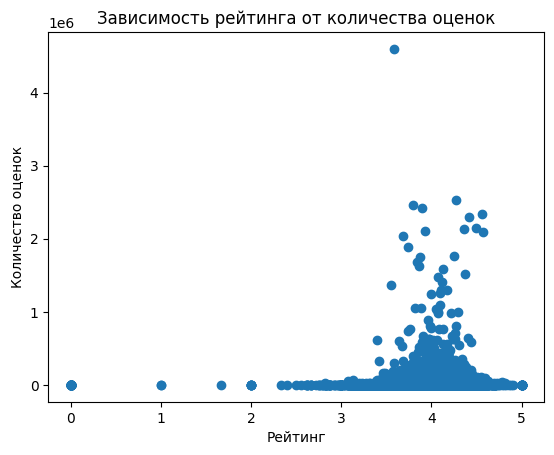

In [50]:
#построение точечной диаграммы
plt.scatter(data['average_rating'], data['ratings_count'])
plt.xlabel('Рейтинг')            #подпись оси х
plt.ylabel('Количество оценок')  #подпись оси y
plt.title('Зависимость рейтинга от количества оценок')  #подпись заголовка
plt.show()

По данной диаграмме можно сказать,что чем больше количество оценок для книги,тем выше ее рейтинг.Здесь присутствует несколько выбросов,слишком отклоняющихся от общего распределения.

## 3.4 Line chart зависимости среднего рейтинга книг от времени

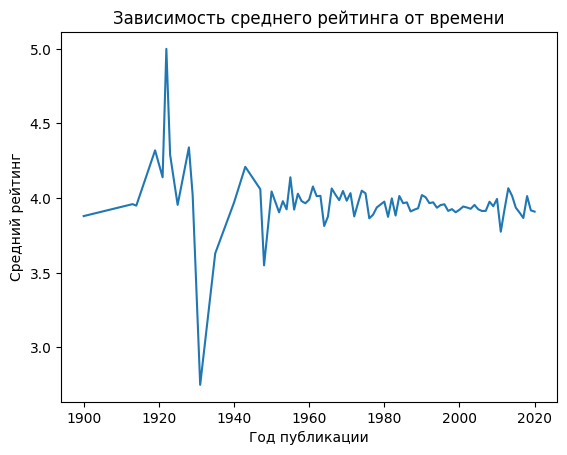

Минимальный средний рейтинг: 2.75 в 1931.0 году
Максимальный средний рейтинг: 5.00 в 1922.0 году


In [51]:
data['publication_date'] = pd.to_datetime(data['publication_date']).dt.year
average_rating_by_year = data.groupby('publication_date')['average_rating'].mean()
plt.plot(average_rating_by_year.index, average_rating_by_year.values)
plt.xlabel('Год публикации')
plt.ylabel('Средний рейтинг')
plt.title('Зависимость среднего рейтинга от времени')
plt.show()

min_year = average_rating_by_year.idxmin()
max_year = average_rating_by_year.idxmax()

# Выводим минимальную точку
print(f"Минимальный средний рейтинг: {average_rating_by_year.min():.2f} в {min_year} году")

# Выводим максимальную точку
print(f"Максимальный средний рейтинг: {average_rating_by_year.max():.2f} в {max_year} году")


После 1960 года отклонение рейтинга от общей тенденции примерно одинаковое.

## 3.5 Сравнение с помощью box plot распределения рейтинга книг, написанных разными авторами.

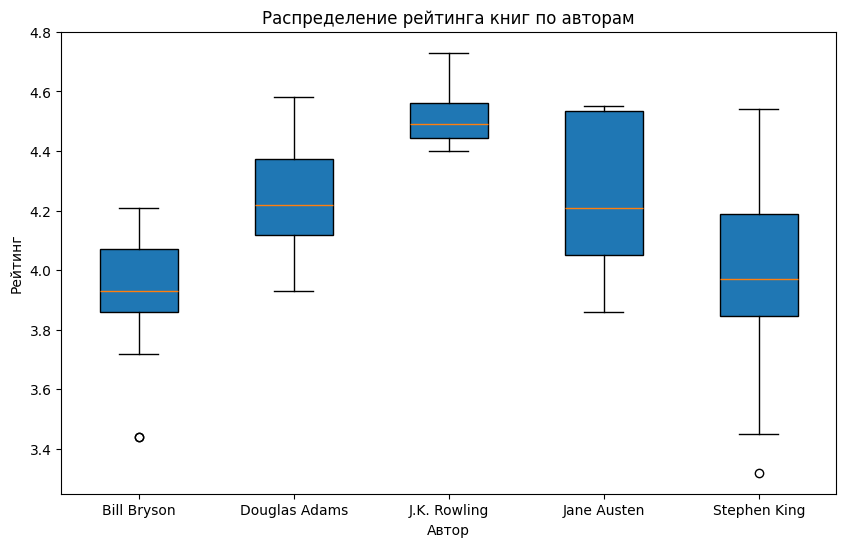

In [52]:
plt.figure(figsize=(10, 6))  # Устанавливаем размер графика

authors_to_plot = ['J.K. Rowling', 'Douglas Adams', 'Bill Bryson', 'Stephen King', 'Jane Austen']
data = data[data['authors'].isin(authors_to_plot)]

# Группируем по автору и рассчитываем средний рейтинг
grouped_data = data.groupby('authors')['average_rating'].apply(list)

plt.boxplot(grouped_data.values.tolist(), tick_labels=grouped_data.index, patch_artist=True)
plt.title('Распределение рейтинга книг по авторам')
plt.xlabel('Автор')
plt.ylabel('Рейтинг')
plt.show()

Средний рейтинг книг у всех авторов находится в диапазоне от 3,9 до 4.5.
Из данной диаграммы boxplot можно сказать,что самым популярным автором из совершенной выборки является J.K.Rowling, а менее популярный автор это Bill Bryson.
У Bill Bryson и Stephen King есть выбросы (точки за пределами усов boxplot), которые свидетельствуют о том, что есть книги этих авторов, которые имеют значительно более низкие или более высокие рейтинги, чем остальные.

## 3.6 Тепловая карта (heatmap) зависимости рейтинга книги от жанра и количества страниц.

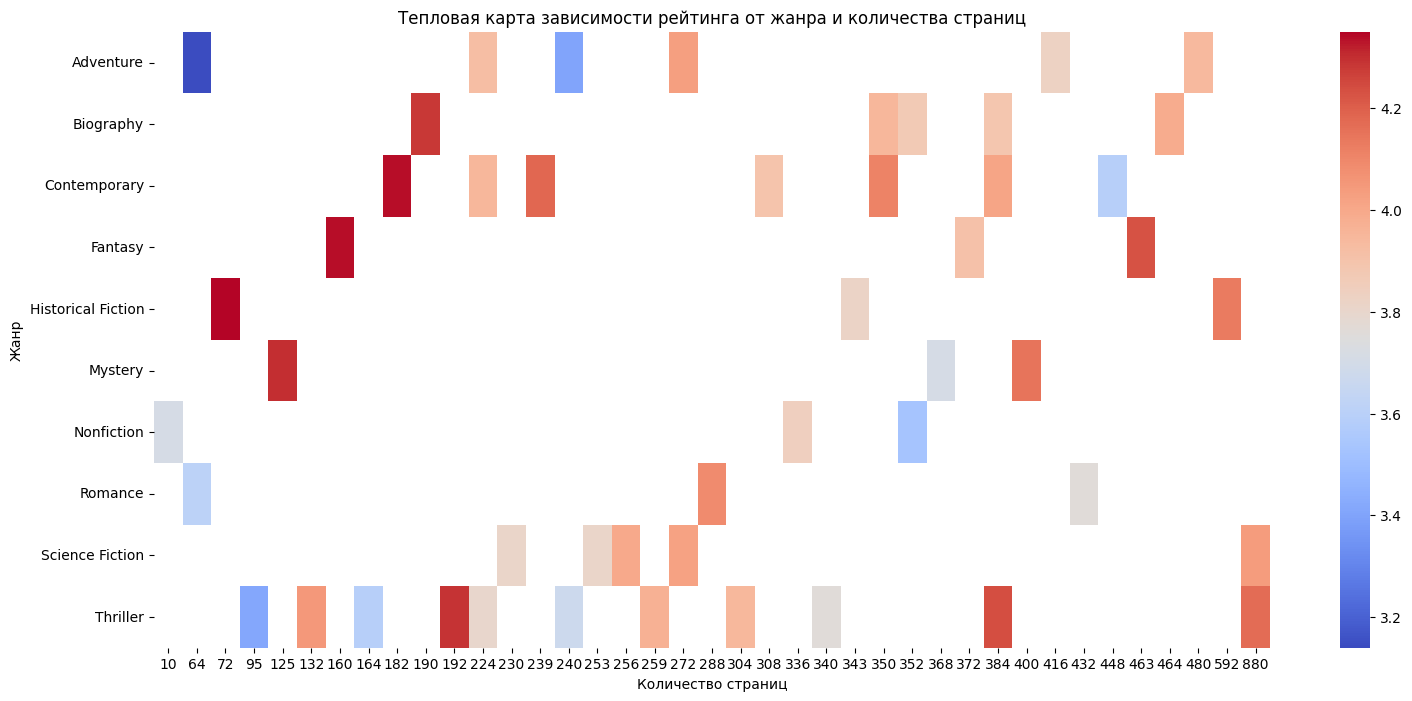

In [53]:
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv("books_updated_data.csv")  # Загрузка данных

# Выбираем книги с количеством страниц от 100 до 500 (например)
data_sl = data[(data['num_pages'] >= 100) & (data['num_pages'] <= 500)]


# Выбираем случайные 100 книг
data_sl = data.sample(n=50, random_state=42)  # random_state для воспроизводимости результатов

pivot_table = data_sl.pivot_table(values='average_rating', index='genres', columns='num_pages', aggfunc='mean')

# Строим тепловую карту
plt.figure(figsize=(18, 8))
sns.heatmap(pivot_table, fmt=".2f", cmap="coolwarm")
plt.title('Тепловая карта зависимости рейтинга от жанра и количества страниц')
plt.xlabel('Количество страниц')
plt.ylabel('Жанр')
plt.show()

Тепловая карта показывает, что рейтинг книг зависят от сочетания жанра и количества страниц. Некоторые жанры, например, “Fantasy” и “Historical Fiction”, чаще всего получают более высокий рейтинг в диапазоне от 70 до 200 страниц, в то время как другие жанры, например, “Thriller” и “Science Fiction”, получают более высокий рейтинг при большем количестве страниц. Это может свидетельствовать о том, что у читателей существуют предпочтения в зависимости от жанра и длины книги.

## 3.7 Bar chart, сравнивающий количество книг, выпущенных в каждом году.

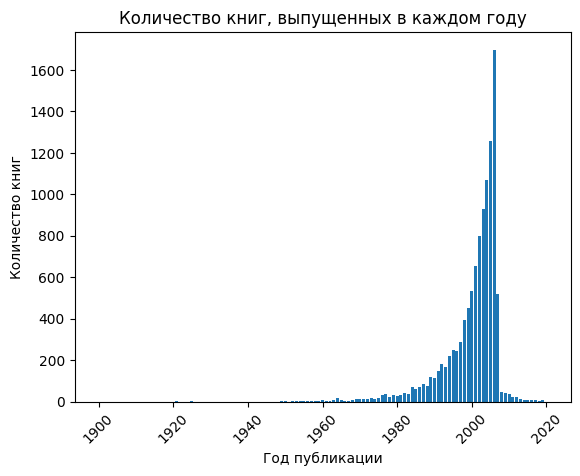

Максимальное количество книг выпущено в 2006.0 году: 1697 книг
Минимальное количество книг выпущено в 1900.0 году: 1 книг


In [58]:
publication_counts = pd.to_datetime(data['publication_date']).dt.year.value_counts().sort_index()
plt.bar(publication_counts.index, publication_counts.values)
plt.xlabel('Год публикации')
plt.ylabel('Количество книг')
plt.title('Количество книг, выпущенных в каждом году')
plt.xticks(rotation=45)
plt.show()

# Находим максимальную и минимальную точки
max_year = publication_counts.idxmax()
min_year = publication_counts.idxmin()

# Выводим максимальную точку
print(f"Максимальное количество книг выпущено в {max_year} году: {publication_counts.max()} книг")

# Выводим минимальную точку
print(f"Минимальное количество книг выпущено в {min_year} году: {publication_counts.min()} книг")

Количество книг, выпущенных в каждом году, постепенно увеличивается с течением времени, особенно начиная с 1980-х годов. После 2010-х годов количество книг, выпущенных в год, пошло на спад.

## 3.8 Scatter plot визуализируйте зависимость рейтинга книги от количества страниц

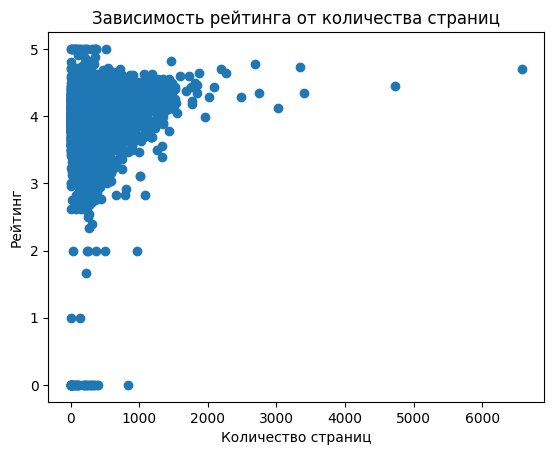

In [55]:
plt.scatter(data['num_pages'], data['average_rating'])
plt.xlabel('Количество страниц')
plt.ylabel('Рейтинг')
plt.title('Зависимость рейтинга от количества страниц')
plt.show()

На диаграмме не наблюдается четкой зависимости между количеством страниц в книге и ее рейтингом.
Большинство точек сконцентрировано в области с количеством страниц от 0 до 1000 и рейтингом от 3 до 5.
Есть несколько точек, которые находятся далеко от основной массы данных (выбросы). Например, есть книга с количеством страниц более 6000 и рейтингом около 4.8, а также несколько книг с небольшим количеством страниц (менее 100) и рейтингом около 2.

## 3.9 Временную шкалу (timeline), отображающую количество книг, выпущенных в каждом году

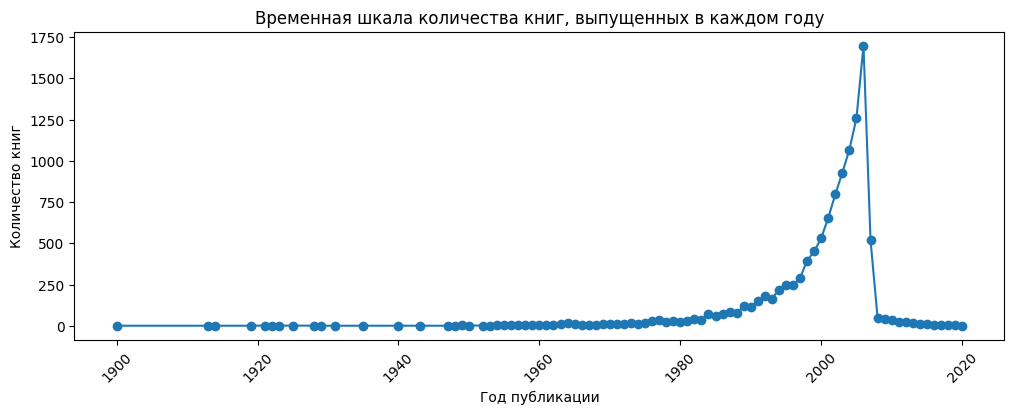

Максимальное количество книг выпущено в 2006.0 году: 1697 книг


In [59]:
publication_counts = pd.to_datetime(data['publication_date']).dt.year.value_counts().sort_index()
plt.figure(figsize=(12, 4))
plt.plot(publication_counts.index, publication_counts.values, marker='o')
plt.xlabel('Год публикации')
plt.ylabel('Количество книг')
plt.title('Временная шкала количества книг, выпущенных в каждом году')
plt.xticks(rotation=45)
plt.show()

# Находим год с максимальным количеством книг
max_year = publication_counts.idxmax()

# Выводим информацию о максимальной точке
print(f"Максимальное количество книг выпущено в {max_year} году: {publication_counts.max()} книг")

## 3.10 Постройте гистограмму распределения количества страниц в книгах

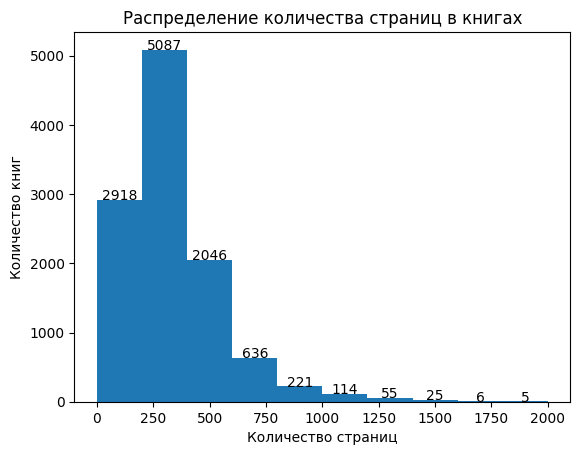

In [28]:
def addlabels(x,y):
    for i in range(len(x)-1):
     x_center = (x[i] + x[i + 1]) / 2
     plt.text(x_center, y[i], str(int(y[i])), ha='center')


plt.hist(data['num_pages'], bins=10, range=(0, 2000), color='blue')
plt.xlabel('Количество страниц')
plt.ylabel('Количество книг')
plt.title('Распределение количества страниц в книгах')

# Получаем значения для подписи столбцов
n, bins, patches = plt.hist(data['num_pages'], bins=10, range=(0, 2000))

# Вызываем функцию addlabels для добавления подписей
addlabels(bins, n)

plt.show()

По данной диаграмме можно сказать,что большее количество книг в датасете имеет количество страниц до 1000 страниц, а самым распространенным является интервал от 250 до 375 страниц.

### Вывод. Перспективы развития проекта

Дополнить dataset: Добавить дополнительные данные о книгах, например, рейтинг на других платформах, количество продаж, отзывы пользователей, информацию о переводах, а также данные о демографических характеристиках читателей.

Применение машинного обучения: Использовать алгоритмы машинного обучения для предсказания популярности книг на основе доступных данных.
Создание веб-приложения: Создать веб-приложение для просмотра и анализа данных о книгах, а также для предсказания популярности книг.